In [2]:
import os
import torch
import numpy as np
import json
import trimesh
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.decomposition import FastICA
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import FloatSlider, interact, HBox, VBox, Box, IntSlider, Dropdown
from IPython.display import display, HTML
import meshplot as mp
from sklearn.decomposition import PCA
from deep_sdf import data, utils, mesh
import deep_sdf.workspace as ws

In [ ]:
# Path to experiment directory
experiment_directory = 'examples/ADNI_1_L_No_MCI/minimal'

# Load specs for paths
specs_filename = os.path.join(experiment_directory, 'specs.json')
specs = json.load(open(specs_filename))

# Mesh root and split files from specs
mesh_root = specs.get('DataSourceMesh', specs['DataSource'])
train_split_file = specs.get('TrainSplit')
test_split_file = specs.get('TestSplit')

# Load train + test splits
split_list = []
seen = set()
for split_file in [train_split_file, test_split_file]:
    if not split_file:
        continue
    with open(split_file, 'r') as f:
        split_data = json.load(f)
    for name in split_data:
        if name not in seen:
            split_list.append(name)
            seen.add(name)
    print(f'Loaded {len(split_data)} examples from {split_file}')

print(f'Total unique examples: {len(split_list)}')


Loaded 696 examples from examples/splits/splits_left_hippocampus_ADNI_No_MCI/train_split_left_hippocampus_adni_no_mci.json
Loaded 77 examples from examples/splits/splits_left_hippocampus_ADNI_No_MCI/test_split_left_hippocampus_adni_no_mci.json
Total unique examples: 773


In [7]:
# Function to sample points from a mesh
def sample_points_from_mesh(mesh_path, n_points=5000):
    try:
        mesh = trimesh.load(mesh_path)
        points, _ = trimesh.sample.sample_surface(mesh, n_points)
        return points.flatten()
    except Exception as e:
        print(f"Error processing {mesh_path}: {e}")
        return None

In [8]:
n_points = 2500  # Number of points to sample from each mesh
point_clouds = []
valid_filenames = []
mesh_objects = {}  # Store mesh objects for later visualization

print('Processing meshes...')
for mesh_name in tqdm(split_list, desc='Processing meshes'):
    mesh_path = os.path.join(mesh_root, mesh_name)
    if os.path.exists(mesh_path):
        points = sample_points_from_mesh(mesh_path, n_points)
        if points is not None:
            point_clouds.append(points)
            valid_filenames.append(f'{mesh_name}')
            mesh_objects[mesh_name] = trimesh.load(mesh_path)
    else:
        print(f'Mesh file not found: {mesh_path}')


Processing meshes...


Processing meshes: 100%|██████████| 773/773 [00:11<00:00, 67.32it/s]


In [9]:
# Convert to numpy array
X = np.array(point_clouds)
print(f"Dataset shape: {X.shape}")

Dataset shape: (773, 7500)


In [10]:
# Load all labels from the label.pt file
labels_path = os.path.join(mesh_root, 'labels.pt')

mesh_params = []
if os.path.exists(labels_path):
    print(f'Loading labels from {labels_path}')
    all_labels = torch.load(labels_path, map_location='cpu')

    # Extract parameters for each filename
    for filename in valid_filenames:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        params = {
            'diagnosis': -1,
            'age': float('nan'),
            'sex': -1,
            'volume': float('nan'),
        }
        if base_name in all_labels:
            label = all_labels[base_name]
            params['diagnosis'] = int(label[0].item())
            params['age'] = float(label[1].item())
            params['sex'] = int(label[2].item())
            params['volume'] = float(label[3].item())
        else:
            print(f'Missing label for {base_name}')
        mesh_params.append(params)
else:
    print(f'labels.pt not found at {labels_path}')


Loading labels from /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt


In [11]:
print(mesh_params)

[{'diagnosis': 0, 'age': 85.0, 'sex': 0, 'volume': 1995.9200439453125}, {'diagnosis': 0, 'age': 85.0, 'sex': 0, 'volume': 2010.5260009765625}, {'diagnosis': 0, 'age': 86.0, 'sex': 0, 'volume': 2144.155517578125}, {'diagnosis': 1, 'age': 78.0, 'sex': 0, 'volume': 1713.1513671875}, {'diagnosis': 1, 'age': 78.0, 'sex': 0, 'volume': 1699.7940673828125}, {'diagnosis': 1, 'age': 79.0, 'sex': 0, 'volume': 1677.5770263671875}, {'diagnosis': 0, 'age': 90.0, 'sex': 1, 'volume': 2409.070556640625}, {'diagnosis': 0, 'age': 90.0, 'sex': 1, 'volume': 2241.165283203125}, {'diagnosis': 0, 'age': 91.0, 'sex': 1, 'volume': 2237.43603515625}, {'diagnosis': 1, 'age': 82.0, 'sex': 1, 'volume': 1309.15625}, {'diagnosis': 1, 'age': 83.0, 'sex': 1, 'volume': 1274.39501953125}, {'diagnosis': 1, 'age': 83.0, 'sex': 1, 'volume': 1305.7447509765625}, {'diagnosis': 1, 'age': 71.0, 'sex': 1, 'volume': 1887.9300537109375}, {'diagnosis': 1, 'age': 71.0, 'sex': 1, 'volume': 1990.788330078125}, {'diagnosis': 1, 'age': 

In [12]:
# Create arrays for visualization based on extracted parameters
diagnosis = np.array([p.get('diagnosis', -1) for p in mesh_params])
age = np.array([p.get('age', float('nan')) for p in mesh_params], dtype=float)
sex = np.array([p.get('sex', -1) for p in mesh_params])
volume = np.array([p.get('volume', float('nan')) for p in mesh_params], dtype=float)


In [13]:
# Step 2: Apply HLLE for non-linear dimensionality reduction
n_neighbors = min(400, len(X) - 1)  # Ensuring n_neighbors is valid
print("Applying HLLE (this may take a while for large datasets)...")
hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors, n_components=8, method='hessian', eigen_solver='dense')
Z = hlle.fit_transform(X)
print(f"HLLE embedding shape: {Z.shape}")

Applying HLLE (this may take a while for large datasets)...
HLLE embedding shape: (773, 8)


In [14]:
# Step 3: Apply ICA for disentanglement
print("Applying FastICA...")
ica = FastICA(n_components=8, random_state=42)
Y = ica.fit_transform(Z)
print(f"ICA components shape: {Y.shape}")

Applying FastICA...
ICA components shape: (773, 8)


In [15]:
# Save the results
np.save('latent_factors.npy', Y)
np.save('hlle_embedding.npy', Z)
with open('valid_filenames.json', 'w') as f:
    json.dump(valid_filenames, f)

In [16]:
# Create a DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Component 1': Y[:, 0],
    'Component 2': Y[:, 1],
    'Filename': valid_filenames,
    'Diagnosis': diagnosis,
    'Age': age,
    'Sex': sex,
    'Volume': volume,
})


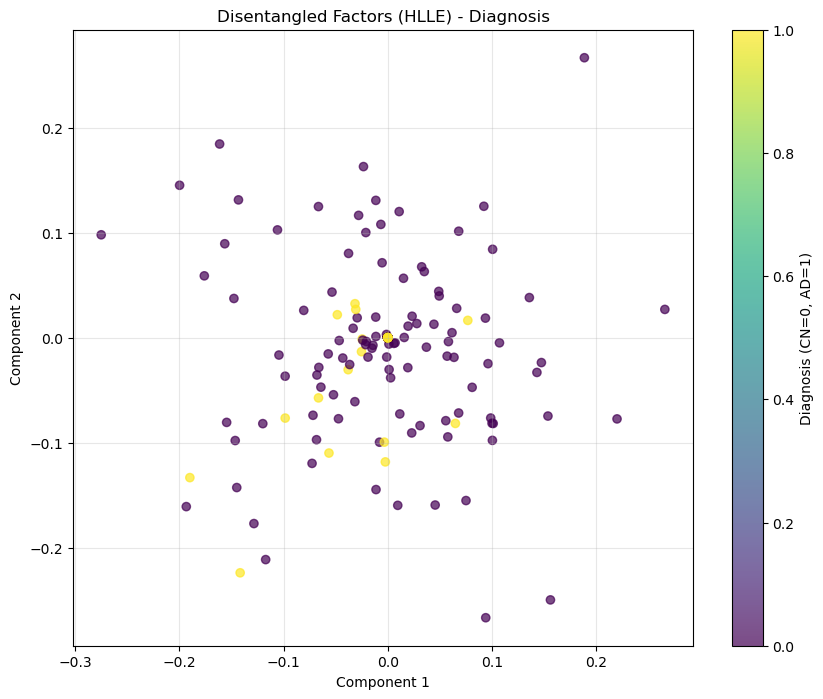

In [17]:
# VISUALIZATION 1: Basic scatter plot (Diagnosis)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=diagnosis, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Diagnosis (CN=0, AD=1)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Disentangled Factors (HLLE) - Diagnosis')
plt.grid(True, alpha=0.3)
plt.savefig('adni_latent_factors_diagnosis.png', dpi=300)
plt.show()


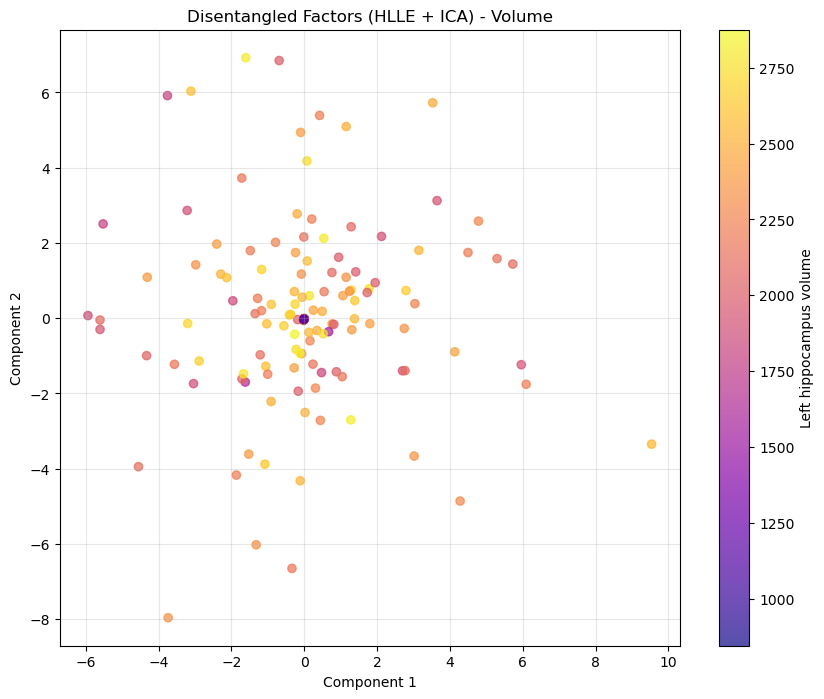

In [18]:
# Alternative coloring by volume
plt.figure(figsize=(10, 8))
mask = np.isfinite(volume)
if np.any(mask):
    scatter = plt.scatter(Y[mask, 0], Y[mask, 1], c=volume[mask], cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, label='Left hippocampus volume')
else:
    scatter = plt.scatter(Y[:, 0], Y[:, 1], alpha=0.7)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Disentangled Factors (HLLE + ICA) - Volume')
plt.grid(True, alpha=0.3)
plt.savefig('adni_latent_factors_volume.png', dpi=300)
plt.show()


In [19]:
# Optional: Correlation analysis
if len(mesh_params) > 0:
    print('\nCorrelation Analysis:')
    for i in range(Y.shape[1]):
        if np.any(diagnosis >= 0):
            mask = diagnosis >= 0
            diag_corr = np.corrcoef(Y[mask, i], diagnosis[mask])[0, 1]
            print(f'Component {i+1} correlation with diagnosis: {diag_corr:.4f}')
        if np.any(np.isfinite(age)):
            mask = np.isfinite(age)
            age_corr = np.corrcoef(Y[mask, i], age[mask])[0, 1]
            print(f'Component {i+1} correlation with age: {age_corr:.4f}')
        if np.any(sex >= 0):
            mask = sex >= 0
            sex_corr = np.corrcoef(Y[mask, i], sex[mask])[0, 1]
            print(f'Component {i+1} correlation with sex: {sex_corr:.4f}')
        if np.any(np.isfinite(volume)):
            mask = np.isfinite(volume)
            vol_corr = np.corrcoef(Y[mask, i], volume[mask])[0, 1]
            print(f'Component {i+1} correlation with volume: {vol_corr:.4f}')



Correlation Analysis:
Component 1 correlation with diagnosis: -0.0004
Component 1 correlation with age: -0.0158
Component 1 correlation with sex: 0.0195
Component 1 correlation with volume: 0.0274
Component 2 correlation with diagnosis: -0.0439
Component 2 correlation with age: 0.0592
Component 2 correlation with sex: 0.0009
Component 2 correlation with volume: 0.0296
Component 3 correlation with diagnosis: -0.0265
Component 3 correlation with age: 0.0299
Component 3 correlation with sex: -0.0284
Component 3 correlation with volume: -0.0074
Component 4 correlation with diagnosis: 0.0282
Component 4 correlation with age: 0.0762
Component 4 correlation with sex: 0.0284
Component 4 correlation with volume: -0.0695
Component 5 correlation with diagnosis: -0.0013
Component 5 correlation with age: 0.0562
Component 5 correlation with sex: 0.0245
Component 5 correlation with volume: -0.0561
Component 6 correlation with diagnosis: -0.0130
Component 6 correlation with age: -0.0628
Component 6 c

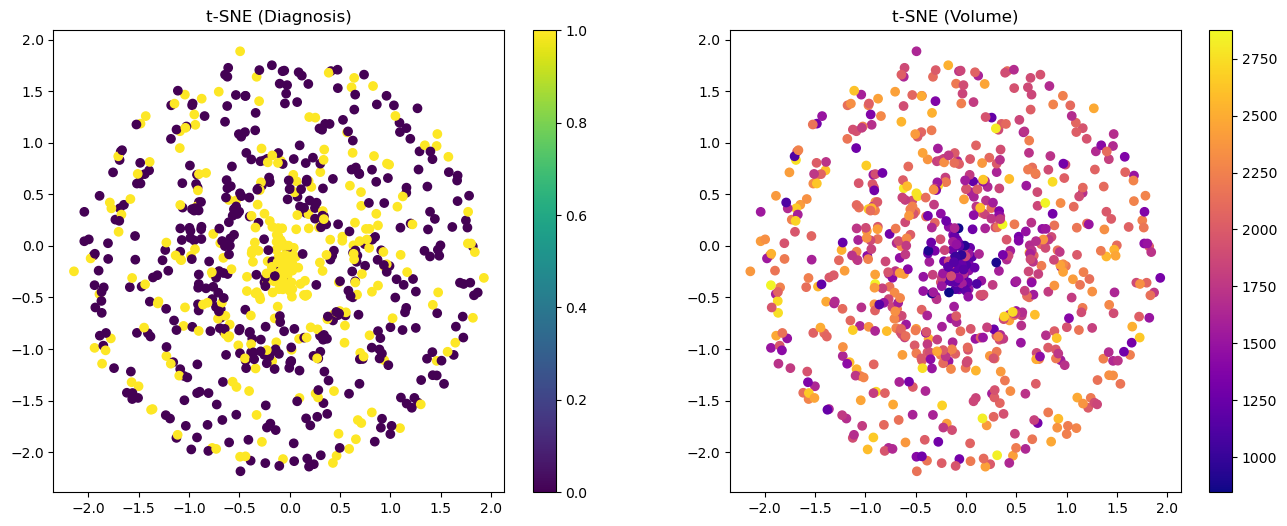

In [20]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Y_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=diagnosis, cmap='viridis')
plt.title('t-SNE (Diagnosis)')
plt.colorbar()

plt.subplot(1, 2, 2)
mask = np.isfinite(volume)
plt.scatter(Y_tsne[mask, 0], Y_tsne[mask, 1], c=volume[mask], cmap='plasma')
plt.title('t-SNE (Volume)')
plt.colorbar()
plt.show()


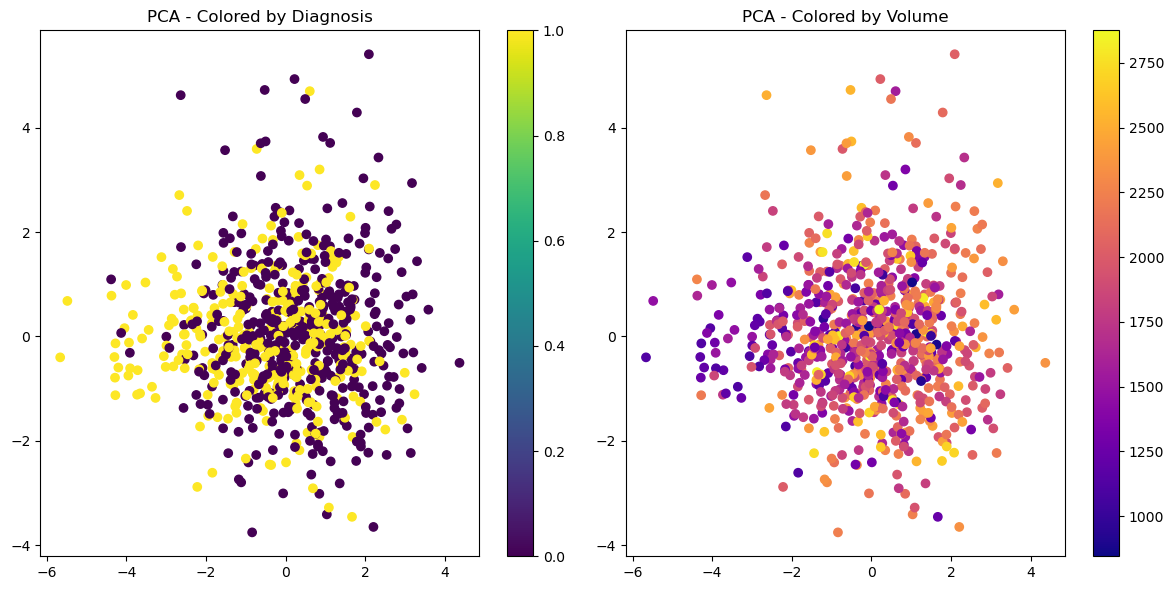

In [21]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
Y_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=diagnosis, cmap='viridis')
plt.title('PCA - Colored by Diagnosis')
plt.colorbar()

plt.subplot(1, 2, 2)
mask = np.isfinite(volume)
plt.scatter(Y_pca[mask, 0], Y_pca[mask, 1], c=volume[mask], cmap='plasma')
plt.title('PCA - Colored by Volume')
plt.colorbar()
plt.tight_layout()
plt.show()


NMF components shape: (773, 4)


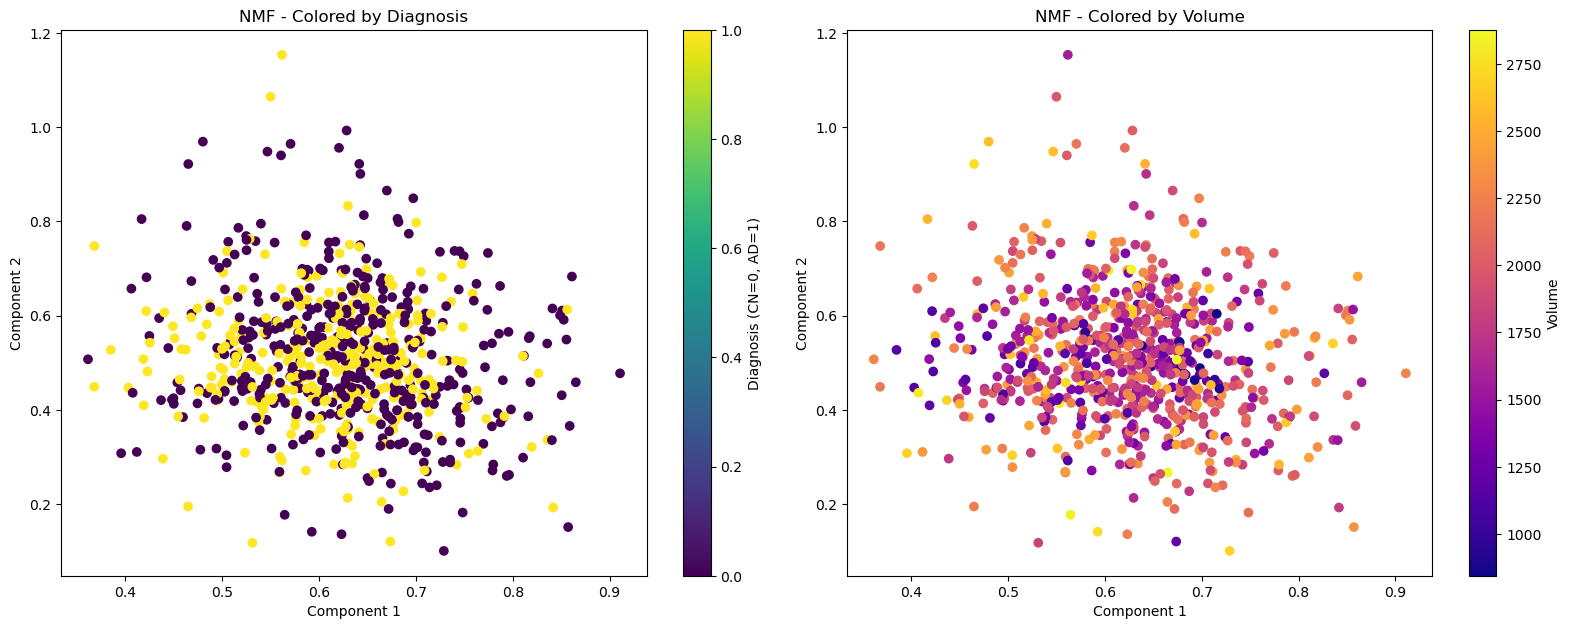

In [22]:
from sklearn.decomposition import NMF
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Ensure data is non-negative
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min
else:
    X_offset = X.copy()

# Step 2: Apply NMF
n_components = 4
nmf = NMF(n_components=n_components, init='random', random_state=42, max_iter=10000)
Y_nmf = nmf.fit_transform(X_offset)

print(f'NMF components shape: {Y_nmf.shape}')

# Step 3: Visualize the results
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.scatter(Y_nmf[:, 0], Y_nmf[:, 1], c=diagnosis, cmap='viridis')
plt.colorbar(label='Diagnosis (CN=0, AD=1)')
plt.title('NMF - Colored by Diagnosis')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.subplot(2, 2, 2)
mask = np.isfinite(volume)
plt.scatter(Y_nmf[mask, 0], Y_nmf[mask, 1], c=volume[mask], cmap='plasma')
plt.colorbar(label='Volume')
plt.title('NMF - Colored by Volume')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.tight_layout()
plt.show()


In [23]:
# Correlation with diagnosis and volume
diag_values = diagnosis
vol_values = volume
for i in range(Y_nmf.shape[1]):
    if np.any(diag_values >= 0):
        mask = diag_values >= 0
        nmf_corr_diag = np.corrcoef(Y_nmf[mask, i], diag_values[mask])[0, 1]
        print(f'NMF Component {i+1} correlation with diagnosis: {nmf_corr_diag:.3f}')
    if np.any(np.isfinite(vol_values)):
        mask = np.isfinite(vol_values)
        nmf_corr_vol = np.corrcoef(Y_nmf[mask, i], vol_values[mask])[0, 1]
        print(f'NMF Component {i+1} correlation with volume: {nmf_corr_vol:.3f}')


NMF Component 1 correlation with diagnosis: -0.105
NMF Component 1 correlation with volume: 0.037
NMF Component 2 correlation with diagnosis: -0.053
NMF Component 2 correlation with volume: 0.026
NMF Component 3 correlation with diagnosis: 0.023
NMF Component 3 correlation with volume: 0.023
NMF Component 4 correlation with diagnosis: 0.021
NMF Component 4 correlation with volume: 0.020


Applying FastICA...
ICA components shape: (773, 2)


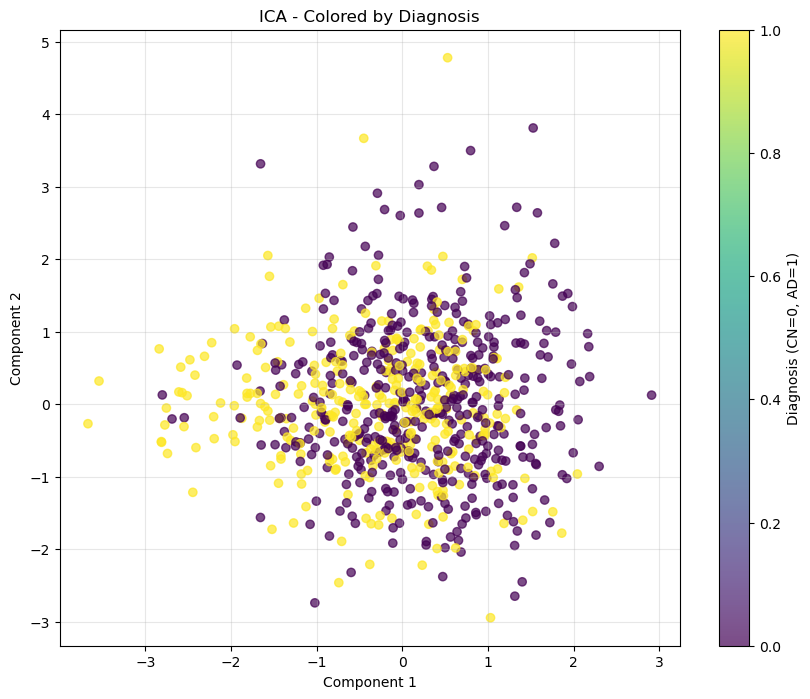

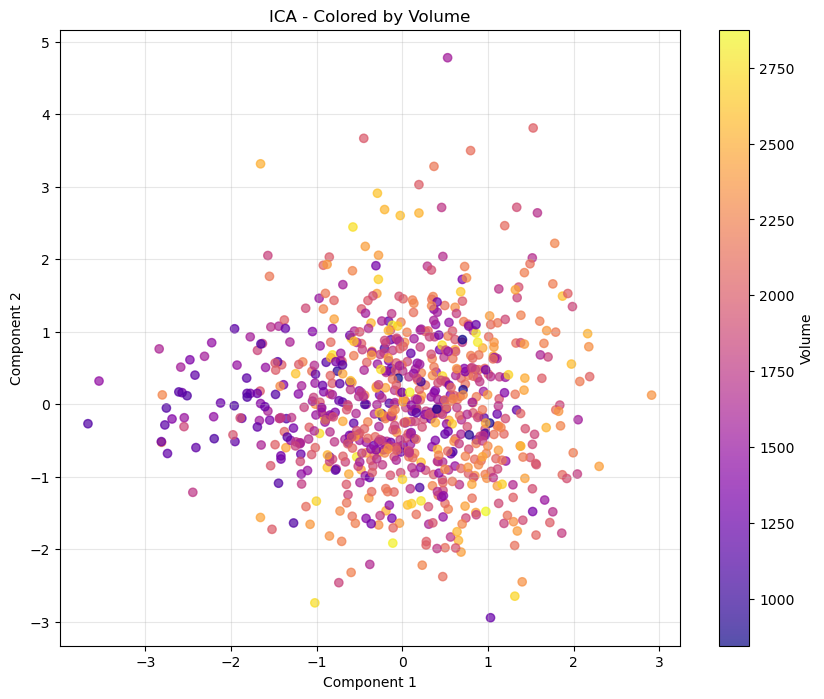

ICA correlation (diag) comp1: -0.280, comp2: -0.041


In [24]:
# Applying only ICA
print('Applying FastICA...')
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
print(f'ICA components shape: {Y_ica.shape}')

plt.figure(figsize=(10, 8))
plt.scatter(Y_ica[:, 0], Y_ica[:, 1], c=diagnosis, cmap='viridis', alpha=0.7)
plt.colorbar(label='Diagnosis (CN=0, AD=1)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('ICA - Colored by Diagnosis')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
mask = np.isfinite(volume)
plt.scatter(Y_ica[mask, 0], Y_ica[mask, 1], c=volume[mask], cmap='plasma', alpha=0.7)
plt.colorbar(label='Volume')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('ICA - Colored by Volume')
plt.grid(True, alpha=0.3)
plt.show()

if np.any(diagnosis >= 0):
    mask = diagnosis >= 0
    ica_corr_diag_1 = np.corrcoef(Y_ica[mask, 0], diagnosis[mask])[0, 1]
    ica_corr_diag_2 = np.corrcoef(Y_ica[mask, 1], diagnosis[mask])[0, 1]
    print(f'ICA correlation (diag) comp1: {ica_corr_diag_1:.3f}, comp2: {ica_corr_diag_2:.3f}')


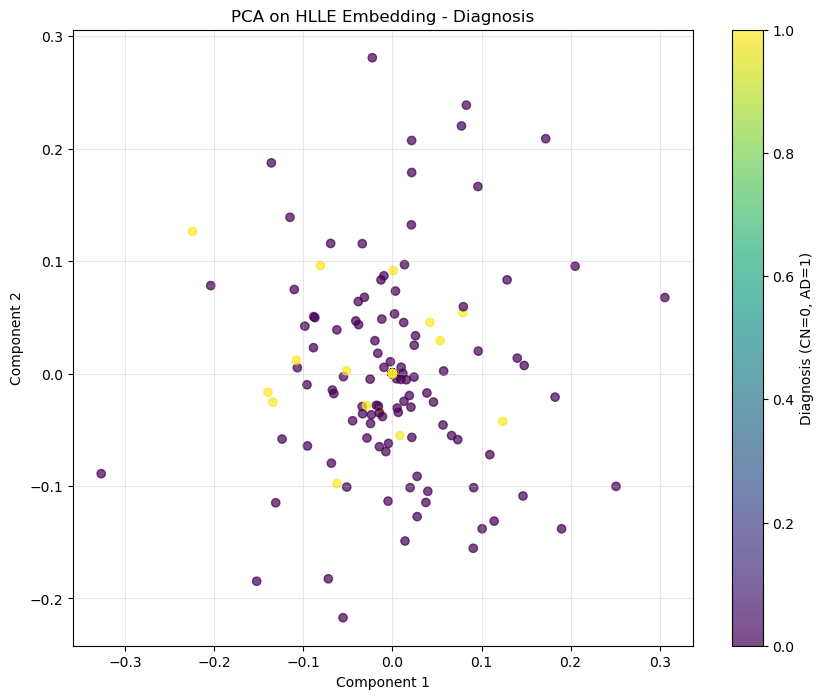

In [25]:
# PCA on the HLLE embedding
pca_hlle = PCA(n_components=2)
Y_pca_hlle = pca_hlle.fit_transform(Z)
plt.figure(figsize=(10, 8))
plt.scatter(Y_pca_hlle[:, 0], Y_pca_hlle[:, 1], c=diagnosis, cmap='viridis', alpha=0.7)
plt.colorbar(label='Diagnosis (CN=0, AD=1)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA on HLLE Embedding - Diagnosis')
plt.grid(True, alpha=0.3)
plt.show()
